## 1. Setup and Dependencies

In [100]:
import os
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
from dotenv import load_dotenv

# NLP Metrics
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load environment variables
load_dotenv('../.env.local')

print("[OK] All dependencies loaded successfully!")

[OK] All dependencies loaded successfully!


## 2. Configuration

In [101]:
# API Configuration - EXACT same as the web app
API_BASE_URL = "http://localhost:3000"
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
PINECONE_INDEX = os.getenv("PINECONE_INDEX", "student-consultation")

# Initialize ROUGE scorer
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Smoothing function for BLEU
smoothing = SmoothingFunction().method1

# HuggingFace Router API for embeddings (same as web app uses)
HF_EMBEDDING_URL = "https://router.huggingface.co/hf-inference/models/sentence-transformers/all-MiniLM-L6-v2/pipeline/feature-extraction"

def get_embeddings_hf(texts: List[str]) -> np.ndarray:
    """Get embeddings from HuggingFace - same as web app."""
    headers = {"Authorization": f"Bearer {HUGGINGFACE_API_KEY}"}
    response = requests.post(HF_EMBEDDING_URL, headers=headers, json={"inputs": texts, "options": {"wait_for_model": True}})
    if response.status_code == 200:
        return np.array(response.json())
    else:
        print(f"HF API error: {response.status_code} - {response.text}")
        return None

# Test APIs
print("[TEST] HuggingFace Embeddings API...")
test_emb = get_embeddings_hf(["Hello world"])
if test_emb is not None:
    print(f"   [OK] Embedding shape: {test_emb.shape}")
else:
    print("   [FAIL] HuggingFace API not available")

[TEST] HuggingFace Embeddings API...
   [OK] Embedding shape: (1, 384)
   [OK] Embedding shape: (1, 384)


## 3. Pinecone RAG Setup

Connect to Pinecone vector database to retrieve context - exactly like the web app does.

In [102]:
from pinecone import Pinecone

# Initialize Pinecone - same as web app
pc = Pinecone(api_key=PINECONE_API_KEY)
index = pc.Index(PINECONE_INDEX)

def query_pinecone(query_text: str, domain: str = None, top_k: int = 5) -> List[Dict]:
    """
    Query Pinecone for relevant context - mirrors lib/agents/coordinator.ts
    The web app routes to domain-specific namespaces based on persona.
    """
    try:
        # Get embedding for query
        query_embedding = get_embeddings_hf([query_text])
        if query_embedding is None:
            return []
        
        query_vector = query_embedding[0].tolist()
        
        # Match web app: query domain-specific namespace 
        # coordinator.ts routes academic -> academic namespace, etc.
        namespace = domain if domain in ['academic', 'career', 'wellness'] else 'general'
        
        results = index.query(
            vector=query_vector,
            top_k=top_k,
            include_metadata=True,
            namespace=namespace
        )
        
        # Extract relevant context
        contexts = []
        for match in results.matches:
            metadata = match.metadata or {}
            # Try all possible text fields (chunkText is VectorMetadata, content is seed data)
            text = (
                metadata.get("chunkText") or 
                metadata.get("content") or 
                metadata.get("text") or
                metadata.get("pageContent") or
                ""
            )
            contexts.append({
                "id": match.id,
                "score": match.score,
                "text": text,
                "category": metadata.get("category", "general"),
                "source": metadata.get("source", "unknown"),
                "namespace": namespace
            })
        
        return contexts
    
    except Exception as e:
        print(f"Pinecone query error: {e}")
        return []


# Test Pinecone connection
print("[TEST] Pinecone Connection...")
try:
    stats = index.describe_index_stats()
    print(f"   [OK] Connected to index: {PINECONE_INDEX}")
    print(f"   Total vectors: {stats.total_vector_count}")
    
    # Check namespaces
    if stats.namespaces:
        print(f"   Namespaces: {list(stats.namespaces.keys())}")
        for ns, ns_stats in stats.namespaces.items():
            print(f"      - {ns}: {ns_stats.vector_count} vectors")
    
    # Test query for each domain namespace (like coordinator does)
    print("\n   Testing domain-specific queries (like coordinator.ts):")
    for domain in ['academic', 'career', 'wellness', 'general']:
        test_q = "How can I improve?" if domain != 'career' else "How do I write a resume?"
        test_contexts = query_pinecone(test_q, domain, 2)
        if test_contexts:
            has_text = bool(test_contexts[0]['text'])
            print(f"      [{domain}] {len(test_contexts)} results, has_text={has_text}, score={test_contexts[0]['score']:.3f}")
        else:
            print(f"      [{domain}] No results")
        
except Exception as e:
    print(f"   [FAIL] Pinecone error: {e}")

[TEST] Pinecone Connection...
   [OK] Connected to index: student-consultation
   Total vectors: 331
   Namespaces: ['academic', 'general', 'wellness', 'career']
      - academic: 53 vectors
      - general: 179 vectors
      - wellness: 49 vectors
      - career: 50 vectors

   Testing domain-specific queries (like coordinator.ts):
   [OK] Connected to index: student-consultation
   Total vectors: 331
   Namespaces: ['academic', 'general', 'wellness', 'career']
      - academic: 53 vectors
      - general: 179 vectors
      - wellness: 49 vectors
      - career: 50 vectors

   Testing domain-specific queries (like coordinator.ts):
      [academic] 2 results, has_text=True, score=0.430
      [academic] 2 results, has_text=True, score=0.430
      [career] 2 results, has_text=True, score=0.707
      [career] 2 results, has_text=True, score=0.707
      [wellness] 2 results, has_text=True, score=0.330
      [wellness] 2 results, has_text=True, score=0.330
      [general] 2 results, has_tex

## 4. Evaluation Test Cases

Test cases for each persona domain with reference answers.

In [103]:
# Test cases with questions and reference answers
TEST_CASES = [
    # Academic Domain
    {
        "id": "academic_1",
        "domain": "academic",
        "question": "How can I improve my study habits for better grades?",
        "reference": "To improve study habits: 1) Use active recall and spaced repetition techniques, 2) Create a consistent study schedule, 3) Find a quiet study environment, 4) Take regular breaks using the Pomodoro technique, 5) Review material before and after class, 6) Get adequate sleep for memory consolidation."
    },
    {
        "id": "academic_2",
        "domain": "academic",
        "question": "What is the Pomodoro Technique and how does it work?",
        "reference": "The Pomodoro Technique is a time management method where you work in focused 25-minute intervals called pomodoros, followed by 5-minute breaks. After 4 pomodoros, take a longer 15-30 minute break. This helps maintain focus and prevents burnout."
    },
    {
        "id": "academic_3",
        "domain": "academic",
        "question": "How should I prepare for final exams?",
        "reference": "For final exam preparation: 1) Start early, at least 2-3 weeks before, 2) Review all course materials and notes, 3) Create summary sheets or flashcards, 4) Practice with past exams, 5) Form study groups, 6) Get enough sleep and exercise, 7) Manage test anxiety with relaxation techniques."
    },
    
    # Career Domain
    {
        "id": "career_1",
        "domain": "career",
        "question": "How do I write a strong resume?",
        "reference": "For a strong resume: 1) Use action verbs and quantify achievements, 2) Tailor it to each job application, 3) Keep it to one page for entry-level, 4) Include contact info, education, experience, and skills, 5) Use a clean, professional format, 6) Proofread carefully for errors."
    },
    {
        "id": "career_2",
        "domain": "career",
        "question": "What is the STAR method for interviews?",
        "reference": "The STAR method is a structured way to answer behavioral interview questions: Situation (describe the context), Task (explain what you needed to do), Action (describe what you did), Result (share the outcome). This helps you give clear, compelling answers."
    },
    {
        "id": "career_3",
        "domain": "career",
        "question": "How can I network effectively as a student?",
        "reference": "Effective networking strategies: 1) Attend career fairs and industry events, 2) Use LinkedIn to connect with professionals, 3) Conduct informational interviews, 4) Join professional associations, 5) Leverage alumni networks, 6) Follow up with contacts regularly, 7) Offer value before asking for help."
    },
    
    # Wellness Domain
    {
        "id": "wellness_1",
        "domain": "wellness",
        "question": "How can I manage stress during exam season?",
        "reference": "To manage exam stress: 1) Practice deep breathing or meditation, 2) Exercise regularly, 3) Maintain a healthy sleep schedule, 4) Break study sessions into manageable chunks, 5) Talk to friends or counselors, 6) Limit caffeine intake, 7) Take regular breaks and do activities you enjoy."
    },
    {
        "id": "wellness_2",
        "domain": "wellness",
        "question": "What is box breathing and how do I do it?",
        "reference": "Box breathing is a relaxation technique: breathe in for 4 counts, hold for 4 counts, breathe out for 4 counts, hold for 4 counts. Repeat 4-6 times. It activates the parasympathetic nervous system to reduce stress and anxiety."
    },
    {
        "id": "wellness_3",
        "domain": "wellness",
        "question": "How can I improve my sleep quality?",
        "reference": "Improve sleep quality by: 1) Maintaining a consistent sleep schedule, 2) Creating a dark, cool, quiet environment, 3) Avoiding screens before bed, 4) Limiting caffeine after 2pm, 5) Exercising regularly but not before bed, 6) Using relaxation techniques, 7) Reserving bed for sleep only."
    },
    
    # General Domain
    {
        "id": "general_1",
        "domain": "general",
        "question": "How does course registration work?",
        "reference": "Course registration typically opens in waves by seniority. Log into the registration system during your assigned window, enter course codes, and confirm enrollment. Have backup courses ready as popular classes fill quickly. You can make changes during the add/drop period."
    },
    {
        "id": "general_2",
        "domain": "general",
        "question": "What is the difference between dropping and withdrawing from a course?",
        "reference": "Dropping a course (during add/drop period) removes it with no record and full refund. Withdrawing (later in semester) leaves a W on your transcript, may have partial/no refund, and could affect financial aid. Drop period is usually the first week; withdrawal deadline is mid-semester."
    }
]

print(f"[OK] Loaded {len(TEST_CASES)} test cases across 4 domains")
print(f"   - Academic: {len([t for t in TEST_CASES if t['domain'] == 'academic'])}")
print(f"   - Career: {len([t for t in TEST_CASES if t['domain'] == 'career'])}")
print(f"   - Wellness: {len([t for t in TEST_CASES if t['domain'] == 'wellness'])}")
print(f"   - General: {len([t for t in TEST_CASES if t['domain'] == 'general'])}")

[OK] Loaded 11 test cases across 4 domains
   - Academic: 3
   - Career: 3
   - Wellness: 3
   - General: 2


## 5. Metric Calculation Functions

In [104]:
def calculate_bleu(reference: str, candidate: str) -> Dict[str, float]:
    """Calculate BLEU scores (1-4 gram) between reference and candidate."""
    ref_tokens = nltk.word_tokenize(reference.lower())
    cand_tokens = nltk.word_tokenize(candidate.lower())
    
    bleu1 = sentence_bleu([ref_tokens], cand_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = sentence_bleu([ref_tokens], cand_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = sentence_bleu([ref_tokens], cand_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = sentence_bleu([ref_tokens], cand_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)
    
    return {"bleu1": bleu1, "bleu2": bleu2, "bleu3": bleu3, "bleu4": bleu4}


def calculate_rouge(reference: str, candidate: str) -> Dict[str, float]:
    """Calculate ROUGE scores between reference and candidate."""
    scores = rouge.score(reference, candidate)
    return {
        "rouge1_f": scores['rouge1'].fmeasure,
        "rouge1_p": scores['rouge1'].precision,
        "rouge1_r": scores['rouge1'].recall,
        "rouge2_f": scores['rouge2'].fmeasure,
        "rougeL_f": scores['rougeL'].fmeasure
    }


def calculate_semantic_similarity(reference: str, candidate: str) -> float:
    """Calculate semantic similarity using HuggingFace embeddings."""
    try:
        embeddings = get_embeddings_hf([reference, candidate])
        if embeddings is None:
            return 0.0
        ref_emb = embeddings[0]
        cand_emb = embeddings[1]
        similarity = np.dot(ref_emb, cand_emb) / (np.linalg.norm(ref_emb) * np.linalg.norm(cand_emb))
        return float(similarity)
    except Exception as e:
        print(f"Semantic similarity error: {e}")
        return 0.0


def evaluate_response(reference: str, candidate: str) -> Dict:
    """Comprehensive evaluation of a response."""
    bleu_scores = calculate_bleu(reference, candidate)
    rouge_scores = calculate_rouge(reference, candidate)
    semantic_sim = calculate_semantic_similarity(reference, candidate)
    return {**bleu_scores, **rouge_scores, "semantic_similarity": semantic_sim}


# Test the functions
test_ref = "The quick brown fox jumps over the lazy dog."
test_cand = "A quick brown fox jumped over a lazy dog."
test_scores = evaluate_response(test_ref, test_cand)
print("[OK] Metric functions working!")
print(f"   Test BLEU-4: {test_scores['bleu4']:.4f}")
print(f"   Test ROUGE-L: {test_scores['rougeL_f']:.4f}")
print(f"   Test Semantic Similarity: {test_scores['semantic_similarity']:.4f}")

[OK] Metric functions working!
   Test BLEU-4: 0.1826
   Test ROUGE-L: 0.7778
   Test Semantic Similarity: 0.9408


## 6. Model Setup (Groq + Gemini)

Using the EXACT models from the web app's modelRotation.ts and geminiClient.ts

In [105]:
from groq import Groq
import google.generativeai as genai

# Initialize clients
groq_client = Groq(api_key=GROQ_API_KEY)
genai.configure(api_key=GEMINI_API_KEY)

# CURRENT GROQ PRODUCTION MODELS (Dec 2025) - from https://console.groq.com/docs/models
GROQ_MODELS = [
    "llama-3.3-70b-versatile",   # Primary - best quality (production)
    "llama-3.1-8b-instant",      # Fast model (production)
]

# Gemini models - current available models (Dec 2025)
GEMINI_MODELS = [
    "gemini-2.0-flash",          # Current flash model
    "gemini-2.5-flash"           # Latest flash model
]

# All models with provider info
ALL_MODELS = [(m, "groq") for m in GROQ_MODELS] + [(m, "gemini") for m in GEMINI_MODELS]

# System prompts - same as lib/ai/promptTemplates.ts
PERSONA_PROMPTS = {
    "academic": """You are an AI academic advisor assistant for university students. 
Provide helpful, accurate advice about studying, academics, and learning strategies. 
Be concise and practical. Use the provided context to enhance your responses.""",
    
    "career": """You are an AI career counselor assistant for university students.
Provide helpful advice about resumes, interviews, networking, and job searching.
Be concise and practical. Use the provided context to enhance your responses.""",
    
    "wellness": """You are an AI wellness guide assistant for university students.
Provide helpful advice about stress management, mental health, sleep, and work-life balance.
Be concise and practical. Use the provided context to enhance your responses.""",
    
    "general": """You are an AI student advisor assistant for university students.
Provide helpful information about university policies, registration, and campus resources.
Be concise and practical. Use the provided context to enhance your responses."""
}


def build_rag_prompt(question: str, domain: str) -> Tuple[str, int]:
    """
    Build prompt with RAG context from Pinecone.
    Mirrors coordinator.ts behavior - queries domain-specific namespace.
    """
    # Query Pinecone with domain-specific namespace (like coordinator does)
    contexts = query_pinecone(question, domain=domain, top_k=3)
    
    # Build context string
    context_str = ""
    if contexts:
        context_str = "\n\nRelevant Context from Knowledge Base:\n"
        for i, ctx in enumerate(contexts, 1):
            if ctx['text']:
                context_str += f"{i}. {ctx['text'][:500]}\n"
    
    # Combine with question
    full_prompt = f"{context_str}\n\nStudent Question: {question}"
    return full_prompt, len(contexts)


def get_groq_response(question: str, domain: str, model: str) -> Tuple[str, float, int]:
    """Get response from Groq API with RAG context."""
    start_time = time.time()
    
    try:
        # Build RAG-enhanced prompt (queries domain namespace)
        rag_prompt, rag_count = build_rag_prompt(question, domain)
        
        response = groq_client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": PERSONA_PROMPTS[domain]},
                {"role": "user", "content": rag_prompt}
            ],
            max_tokens=500,
            temperature=0.7
        )
        
        latency = time.time() - start_time
        content = response.choices[0].message.content
        return content, latency, rag_count
    
    except Exception as e:
        print(f"   [ERROR] Groq {model}: {e}")
        return "", time.time() - start_time, 0


def get_gemini_response(question: str, domain: str, model: str) -> Tuple[str, float, int]:
    """Get response from Gemini API with RAG context."""
    start_time = time.time()
    
    try:
        # Build RAG-enhanced prompt (queries domain namespace)
        rag_prompt, rag_count = build_rag_prompt(question, domain)
        
        gemini_model = genai.GenerativeModel(
            model_name=model,
            system_instruction=PERSONA_PROMPTS[domain]
        )
        
        response = gemini_model.generate_content(
            rag_prompt,
            generation_config=genai.GenerationConfig(
                max_output_tokens=500,
                temperature=0.7
            )
        )
        
        latency = time.time() - start_time
        content = response.text
        return content, latency, rag_count
    
    except Exception as e:
        print(f"   [ERROR] Gemini {model}: {e}")
        return "", time.time() - start_time, 0


def get_model_response(question: str, domain: str, model: str, provider: str) -> Tuple[str, float, int]:
    """Unified response function."""
    if provider == "groq":
        return get_groq_response(question, domain, model)
    elif provider == "gemini":
        return get_gemini_response(question, domain, model)
    return "", 0.0, 0


# Test all APIs
print("[TEST] Testing Model APIs...")
print("-" * 60)

# Test Groq with domain-specific RAG
print("Testing Groq (llama-3.1-8b-instant) with academic domain RAG...")
resp, lat, rag = get_groq_response("What is active recall?", "academic", "llama-3.1-8b-instant")
if resp:
    print(f"   [OK] Response: {len(resp)} chars, Latency: {lat:.2f}s, RAG docs: {rag}")
else:
    print("   [FAIL] Groq not working")

# Test Gemini with domain-specific RAG
print("\nTesting Gemini (gemini-2.0-flash) with career domain RAG...")
resp, lat, rag = get_gemini_response("How do I write a resume?", "career", "gemini-2.0-flash")
if resp:
    print(f"   [OK] Response: {len(resp)} chars, Latency: {lat:.2f}s, RAG docs: {rag}")
else:
    print("   [FAIL] Gemini not working")

print("-" * 60)
print(f"[OK] Ready to evaluate {len(ALL_MODELS)} models ({len(GROQ_MODELS)} Groq + {len(GEMINI_MODELS)} Gemini)")

[TEST] Testing Model APIs...
------------------------------------------------------------
Testing Groq (llama-3.1-8b-instant) with academic domain RAG...
   [OK] Response: 505 chars, Latency: 1.30s, RAG docs: 3

Testing Gemini (gemini-2.0-flash) with career domain RAG...
   [OK] Response: 505 chars, Latency: 1.30s, RAG docs: 3

Testing Gemini (gemini-2.0-flash) with career domain RAG...
   [OK] Response: 1734 chars, Latency: 6.03s, RAG docs: 3
------------------------------------------------------------
[OK] Ready to evaluate 4 models (2 Groq + 2 Gemini)
   [OK] Response: 1734 chars, Latency: 6.03s, RAG docs: 3
------------------------------------------------------------
[OK] Ready to evaluate 4 models (2 Groq + 2 Gemini)


## 7. Run Full Evaluation with RAG

In [106]:
def run_evaluation(models: List[Tuple[str, str]], test_cases: List[Dict]) -> pd.DataFrame:
    """Run full evaluation across all models and test cases with RAG."""
    results = []
    total_tests = len(models) * len(test_cases)
    current = 0
    
    for model, provider in models:
        print(f"\n[EVAL] {provider.upper()}: {model}")
        
        for test in test_cases:
            current += 1
            print(f"   [{current}/{total_tests}] {test['id']}...", end=" ")
            
            # Get model response with RAG
            response, latency, rag_docs = get_model_response(
                test["question"], test["domain"], model, provider
            )
            
            if not response:
                print("[FAIL]")
                continue
            
            # Calculate metrics
            metrics = evaluate_response(test["reference"], response)
            
            results.append({
                "model": model,
                "provider": provider,
                "test_id": test["id"],
                "domain": test["domain"],
                "question": test["question"][:50] + "...",
                "rag_docs_used": rag_docs,
                "latency_s": latency,
                "response_length": len(response),
                **metrics
            })
            
            print(f"[OK] BLEU-4: {metrics['bleu4']:.3f}, Semantic: {metrics['semantic_similarity']:.3f}, RAG: {rag_docs}")
            time.sleep(0.3)  # Rate limit
    
    return pd.DataFrame(results)


# Run evaluation
print("=" * 70)
print("STUDENT CONSULTATION AI - MODEL EVALUATION WITH RAG")
print("=" * 70)
results_df = run_evaluation(ALL_MODELS, TEST_CASES)
print("\n" + "=" * 70)
print(f"[DONE] Evaluation complete! {len(results_df)} results collected.")

STUDENT CONSULTATION AI - MODEL EVALUATION WITH RAG

[EVAL] GROQ: llama-3.3-70b-versatile
   [1/44] academic_1... [OK] BLEU-4: 0.005, Semantic: 0.668, RAG: 3
[OK] BLEU-4: 0.005, Semantic: 0.668, RAG: 3
   [2/44] academic_2...    [2/44] academic_2... [OK] BLEU-4: 0.063, Semantic: 0.781, RAG: 3
[OK] BLEU-4: 0.063, Semantic: 0.781, RAG: 3
   [3/44] academic_3...    [3/44] academic_3... [OK] BLEU-4: 0.017, Semantic: 0.921, RAG: 3
[OK] BLEU-4: 0.017, Semantic: 0.921, RAG: 3
   [4/44] career_1...    [4/44] career_1... [OK] BLEU-4: 0.062, Semantic: 0.864, RAG: 3
[OK] BLEU-4: 0.062, Semantic: 0.864, RAG: 3
   [5/44] career_2...    [5/44] career_2... [OK] BLEU-4: 0.057, Semantic: 0.917, RAG: 3
[OK] BLEU-4: 0.057, Semantic: 0.917, RAG: 3
   [6/44] career_3...    [6/44] career_3... [OK] BLEU-4: 0.019, Semantic: 0.753, RAG: 3
[OK] BLEU-4: 0.019, Semantic: 0.753, RAG: 3
   [7/44] wellness_1...    [7/44] wellness_1... [OK] BLEU-4: 0.050, Semantic: 0.861, RAG: 3
[OK] BLEU-4: 0.050, Semantic: 0.861, R

In [107]:
# Results by Model
print("\n" + "=" * 80)
print("RESULTS BY MODEL")
print("=" * 80)

model_summary = results_df.groupby(['provider', 'model']).agg({
    'bleu1': 'mean',
    'bleu4': 'mean',
    'rouge1_f': 'mean',
    'rougeL_f': 'mean',
    'semantic_similarity': 'mean',
    'latency_s': 'mean',
    'rag_docs_used': 'mean',
    'response_length': 'mean'
}).round(4)

model_summary.columns = ['BLEU-1', 'BLEU-4', 'ROUGE-1', 'ROUGE-L', 'Semantic', 'Latency(s)', 'RAG Docs', 'Resp Len']
display(model_summary)


RESULTS BY MODEL


BLEU-1  BLEU-4  ROUGE-1  ROUGE-L  Semantic  \
provider model                                                                 
gemini   gemini-2.0-flash         0.2305  0.0659   0.3680   0.2759    0.7978   
         gemini-2.5-flash         0.2190  0.0651   0.3704   0.2841    0.8005   
groq     llama-3.1-8b-instant     0.1358  0.0276   0.2574   0.1885    0.7875   
         llama-3.3-70b-versatile  0.1952  0.0441   0.3402   0.2548    0.8284   

                                  Latency(s)  RAG Docs   Resp Len  
provider model                                                     
gemini   gemini-2.0-flash             2.6916       3.0   804.8000  
         gemini-2.5-flash             2.9279       3.0   843.5556  
groq     llama-3.1-8b-instant         1.2575       3.0  1474.2727  
         llama-3.3-70b-versatile      1.3579       3.0   977.0000

In [108]:
# Results by Domain
print("\n" + "=" * 80)
print("RESULTS BY DOMAIN")
print("=" * 80)

domain_summary = results_df.groupby('domain').agg({
    'bleu4': 'mean',
    'rouge1_f': 'mean',
    'rougeL_f': 'mean',
    'semantic_similarity': 'mean',
    'rag_docs_used': 'mean',
    'latency_s': 'mean'
}).round(4)

domain_summary.columns = ['BLEU-4', 'ROUGE-1', 'ROUGE-L', 'Semantic', 'RAG Docs', 'Latency(s)']
display(domain_summary)


RESULTS BY DOMAIN


,BLEU-4,ROUGE-1,ROUGE-L,Semantic,RAG Docs,Latency(s)
domain,,,,,,
academic,0.0600,0.3343,0.2709,0.7887,3.0,1.8687
career,0.0411,0.2935,0.1954,0.8012,3.0,2.1450
general,0.0549,0.3446,0.2565,0.8354,3.0,2.0693
wellness,0.0438,0.3569,0.2738,0.7986,3.0,1.9392


## 8. Visualizations

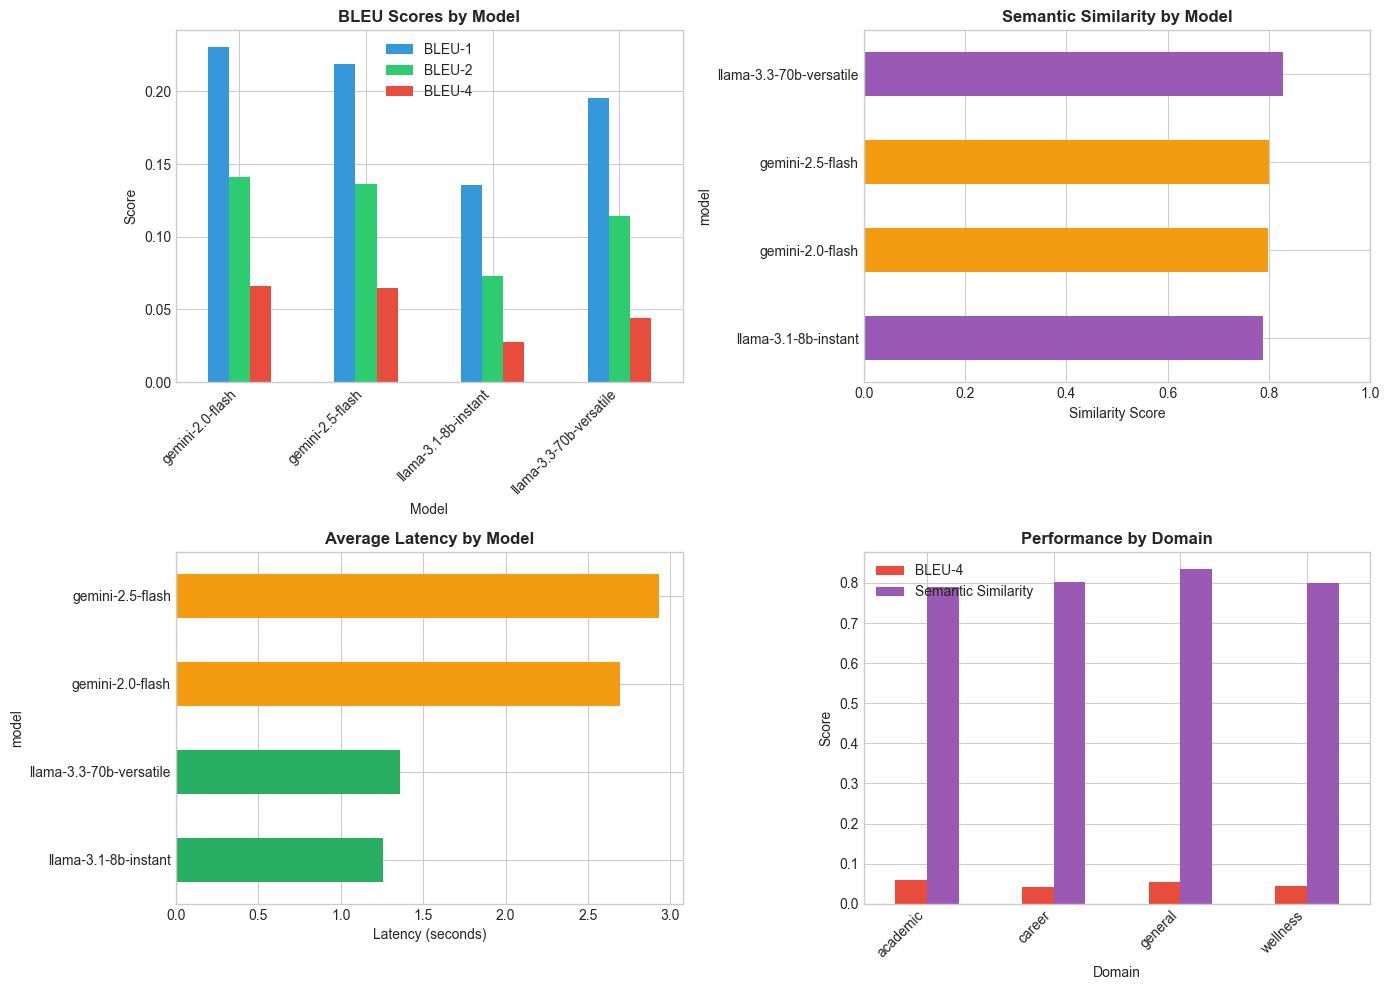

In [109]:
# Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. BLEU Scores by Model
ax1 = axes[0, 0]
bleu_data = results_df.groupby('model')[['bleu1', 'bleu2', 'bleu4']].mean()
bleu_data.plot(kind='bar', ax=ax1, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.set_title('BLEU Scores by Model', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.legend(['BLEU-1', 'BLEU-2', 'BLEU-4'])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 2. Semantic Similarity by Model
ax2 = axes[0, 1]
sem_data = results_df.groupby('model')['semantic_similarity'].mean().sort_values(ascending=True)
colors = ['#9b59b6' if 'gemini' not in m else '#f39c12' for m in sem_data.index]
sem_data.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('Semantic Similarity by Model', fontsize=12, fontweight='bold')
ax2.set_xlabel('Similarity Score')
ax2.set_xlim(0, 1)

# 3. Latency by Model
ax3 = axes[1, 0]
latency_data = results_df.groupby('model')['latency_s'].mean().sort_values(ascending=True)
colors = ['#27ae60' if x < 2 else '#f39c12' if x < 4 else '#e74c3c' for x in latency_data.values]
latency_data.plot(kind='barh', ax=ax3, color=colors)
ax3.set_title('Average Latency by Model', fontsize=12, fontweight='bold')
ax3.set_xlabel('Latency (seconds)')

# 4. Performance by Domain
ax4 = axes[1, 1]
domain_perf = results_df.groupby('domain')[['bleu4', 'semantic_similarity']].mean()
domain_perf.plot(kind='bar', ax=ax4, color=['#e74c3c', '#9b59b6'])
ax4.set_title('Performance by Domain', fontsize=12, fontweight='bold')
ax4.set_xlabel('Domain')
ax4.set_ylabel('Score')
ax4.legend(['BLEU-4', 'Semantic Similarity'])
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

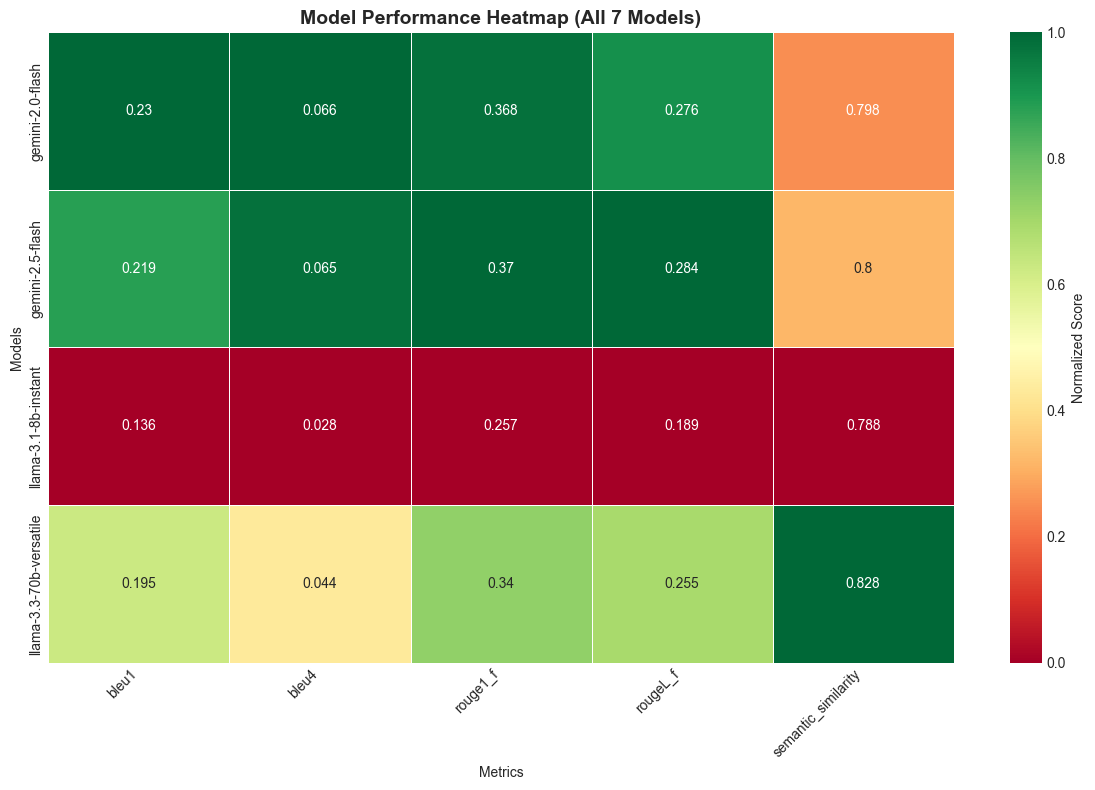

In [110]:
# Model Performance Heatmap
metrics = ['bleu1', 'bleu4', 'rouge1_f', 'rougeL_f', 'semantic_similarity']
heatmap_data = results_df.groupby('model')[metrics].mean()

# Normalize for heatmap
heatmap_normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_normalized, annot=heatmap_data.round(3), fmt='', cmap='RdYlGn', 
            linewidths=0.5, cbar_kws={'label': 'Normalized Score'})
plt.title('Model Performance Heatmap (All 7 Models)', fontsize=14, fontweight='bold')
plt.xlabel('Metrics')
plt.ylabel('Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Detailed Results

In [111]:
# Summary Statistics
print("=" * 80)
print("SUMMARY STATISTICS BY MODEL")
print("=" * 80)

summary_stats = results_df.groupby('model').agg({
    'bleu1': ['mean', 'std'],
    'bleu4': ['mean', 'std'],
    'rouge1_f': ['mean', 'std'],
    'rougeL_f': ['mean', 'std'],
    'semantic_similarity': ['mean', 'std'],
    'latency_s': ['mean', 'std']
}).round(4)

display(summary_stats)

print("\n" + "=" * 80)
print("ALL EVALUATION RESULTS")
print("=" * 80)
display(results_df)

SUMMARY STATISTICS BY MODEL


bleu1           bleu4         rouge1_f          \
                           mean     std    mean     std     mean     std   
model                                                                      
gemini-2.0-flash         0.2305  0.1150  0.0659  0.0665   0.3680  0.1256   
gemini-2.5-flash         0.2190  0.0858  0.0651  0.0646   0.3704  0.1130   
llama-3.1-8b-instant     0.1358  0.0445  0.0276  0.0200   0.2574  0.0769   
llama-3.3-70b-versatile  0.1952  0.0508  0.0441  0.0305   0.3402  0.0824   

                        rougeL_f         semantic_similarity          \
                            mean     std                mean     std   
model                                                                  
gemini-2.0-flash          0.2759  0.1411              0.7978  0.0649   
gemini-2.5-flash          0.2841  0.1330              0.8005  0.0915   
llama-3.1-8b-instant      0.1885  0.0732              0.7875  0.0592   
llama-3.3-70b-versatile   0.2548  0.0948              0.8284  0.0740   

                        latency_s          
                             mean     std  
model                                      
gemini-2.0-flash           2.6916  0.5692  
gemini-2.5-flash           2.9279  0.6100  
llama-3.1-8b-instant       1.2575  0.2208  
llama-3.3-70b-versatile    1.3579  0.1405


ALL EVALUATION RESULTS


,model,provider,test_id,domain,question,rag_docs_used,latency_s,response_length,bleu1,bleu2,bleu3,bleu4,rouge1_f,rouge1_p,rouge1_r,rouge2_f,rougeL_f,semantic_similarity
0,llama-3.3-70b-versatile,groq,academic_1,academic,How can I improve my study habits for better g...,3,1.610813,1167,0.117073,0.041493,0.009917,0.004527,0.160000,0.100559,0.391304,0.026906,0.106667,0.667756
1,llama-3.3-70b-versatile,groq,academic_2,academic,What is the Pomodoro Technique and how does it...,3,1.182194,817,0.195402,0.116421,0.084089,0.063373,0.382022,0.246377,0.850000,0.227273,0.359551,0.781178
2,llama-3.3-70b-versatile,groq,academic_3,academic,How should I prepare for final exams?...,3,1.149124,936,0.215311,0.111453,0.058111,0.017194,0.385787,0.255034,0.791667,0.133333,0.263959,0.921420
3,llama-3.3-70b-versatile,groq,career_1,career,How do I write a strong resume?...,3,1.326839,1056,0.193133,0.125765,0.090306,0.062114,0.339623,0.216867,0.782609,0.123810,0.207547,0.864119
4,llama-3.3-70b-versatile,groq,career_2,career,What is the STAR method for interviews?...,3,1.230992,765,0.195652,0.113268,0.081053,0.057465,0.369427,0.245763,0.743590,0.180645,0.318471,0.917288
5,llama-3.3-70b-versatile,groq,career_3,career,How can I network effectively as a student?...,3,1.412747,1089,0.192118,0.111194,0.064423,0.018728,0.354167,0.226667,0.809524,0.136842,0.218750,0.753449
6,llama-3.3-70b-versatile,groq,wellness_1,wellness,How can I manage stress during exam season?...,3,1.499959,1111,0.195652,0.116919,0.073026,0.050177,0.325581,0.205882,0.777778,0.112676,0.176744,0.860574
7,llama-3.3-70b-versatile,groq,wellness_2,wellness,What is box breathing and how do I do it?...,3,1.387778,653,0.325397,0.233809,0.177316,0.114527,0.493333,0.333333,0.948718,0.270270,0.440000,0.826839
8,llama-3.3-70b-versatile,groq,wellness_3,wellness,How can I improve my sleep quality?...,3,1.342780,1066,0.188000,0.095185,0.049333,0.025809,0.362832,0.225275,0.931818,0.178571,0.309735,0.806602
9,llama-3.3-70b-versatile,groq,general_1,general,How does course registration work?...,3,1.482262,1081,0.150442,0.093232,0.063259,0.038014,0.274882,0.170588,0.707317,0.105263,0.199052,0.847504


## 10. Summary Report

In [112]:
# Final Summary Report
print("=" * 80)
print("STUDENT CONSULTATION AI - MODEL EVALUATION REPORT")
print("=" * 80)
print("Models Evaluated:")
print("  GROQ: llama-3.3-70b-versatile, llama-3.1-8b-instant")
print("  GEMINI: gemini-2.0-flash, gemini-2.5-flash")
print("  RAG: Pinecone vector store for context retrieval")
print("=" * 80)

# Best overall model (weighted score)
def calculate_weighted_score(row):
    return (
        row['bleu4'] * 0.15 +
        row['rouge1_f'] * 0.15 +
        row['rougeL_f'] * 0.15 +
        row['semantic_similarity'] * 0.35 +
        (1 / (row['latency_s'] + 1)) * 0.20  # Lower latency is better
    )

model_scores = results_df.groupby('model').agg({
    'bleu4': 'mean',
    'rouge1_f': 'mean',
    'rougeL_f': 'mean',
    'semantic_similarity': 'mean',
    'latency_s': 'mean',
    'rag_docs_used': 'mean'
})

model_scores['weighted_score'] = model_scores.apply(calculate_weighted_score, axis=1)
best_model = model_scores['weighted_score'].idxmax()

print(f"\n[BEST MODEL] {best_model}")
print(f"   Weighted Score: {model_scores.loc[best_model, 'weighted_score']:.4f}")
print(f"   BLEU-4: {model_scores.loc[best_model, 'bleu4']:.4f}")
print(f"   ROUGE-L: {model_scores.loc[best_model, 'rougeL_f']:.4f}")
print(f"   Semantic Similarity: {model_scores.loc[best_model, 'semantic_similarity']:.4f}")
print(f"   Avg Latency: {model_scores.loc[best_model, 'latency_s']:.2f}s")
print(f"   Avg RAG Docs: {model_scores.loc[best_model, 'rag_docs_used']:.1f}")

print("\n" + "-" * 80)
print("MODEL RANKINGS (by Weighted Score)")
print("-" * 80)

rankings_df = model_scores[['bleu4', 'rouge1_f', 'rougeL_f', 'semantic_similarity', 'latency_s', 'rag_docs_used', 'weighted_score']].sort_values('weighted_score', ascending=False)
rankings_df.columns = ['BLEU-4', 'ROUGE-1', 'ROUGE-L', 'Semantic', 'Latency(s)', 'RAG Docs', 'Score']
display(rankings_df.round(4))

# Provider comparison
print("\n" + "-" * 80)
print("PROVIDER COMPARISON (Groq vs Gemini)")
print("-" * 80)
provider_stats = results_df.groupby('provider').agg({
    'semantic_similarity': 'mean',
    'bleu4': 'mean',
    'latency_s': 'mean'
}).round(4)
provider_stats.columns = ['Semantic Sim', 'BLEU-4', 'Avg Latency(s)']
display(provider_stats)

print("\n" + "=" * 80)
print("Evaluation Complete!")
print("=" * 80)

STUDENT CONSULTATION AI - MODEL EVALUATION REPORT
Models Evaluated:
  GROQ: llama-3.3-70b-versatile, llama-3.1-8b-instant
  GEMINI: gemini-2.0-flash, gemini-2.5-flash
  RAG: Pinecone vector store for context retrieval

[BEST MODEL] llama-3.3-70b-versatile
   Weighted Score: 0.4706
   BLEU-4: 0.0441
   ROUGE-L: 0.2548
   Semantic Similarity: 0.8284
   Avg Latency: 1.36s
   Avg RAG Docs: 3.0

--------------------------------------------------------------------------------
MODEL RANKINGS (by Weighted Score)
--------------------------------------------------------------------------------


,BLEU-4,ROUGE-1,ROUGE-L,Semantic,Latency(s),RAG Docs,Score
model,,,,,,,
llama-3.3-70b-versatile,0.0441,0.3402,0.2548,0.8284,1.3579,3.0,0.4706
gemini-2.0-flash,0.0659,0.3680,0.2759,0.7978,2.6916,3.0,0.4399
gemini-2.5-flash,0.0651,0.3704,0.2841,0.8005,2.9279,3.0,0.4390
llama-3.1-8b-instant,0.0276,0.2574,0.1885,0.7875,1.2575,3.0,0.4353



--------------------------------------------------------------------------------
PROVIDER COMPARISON (Groq vs Gemini)
--------------------------------------------------------------------------------


,Semantic Sim,BLEU-4,Avg Latency(s)
provider,,,
gemini,0.7990,0.0655,2.8035
groq,0.8079,0.0358,1.3077



Evaluation Complete!
